# 01 - Market Discovery
Systematically find all Polymarket contracts relevant to supply chain disruption.

In [1]:
import sys
sys.path.insert(0, "..")
import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(name)s: %(message)s")

import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

## Step 1: Initialize the Polymarket client and run market discovery

In [2]:
import time
from pathlib import Path
from src.polymarket.client import PolymarketClient
from src.polymarket.market_discovery import MarketDiscovery, load_discovered_markets

CACHE_PATH = Path('../data/processed/discovered_markets.csv')
CACHE_MAX_AGE_HOURS = 24  # set to 0 to always re-discover

def _cache_age_hours(path: Path) -> float:
    return (time.time() - path.stat().st_mtime) / 3600

if CACHE_PATH.exists() and _cache_age_hours(CACHE_PATH) < CACHE_MAX_AGE_HOURS:
    markets_df = load_discovered_markets()
    age_h = _cache_age_hours(CACHE_PATH)
    print(f'Loaded {len(markets_df)} markets from cache ({age_h:.1f}h old).')
    print('Set CACHE_MAX_AGE_HOURS=0 or delete data/processed/discovered_markets.csv to re-discover.')
else:
    client = PolymarketClient()
    discovery = MarketDiscovery(client)
    print('Running market discovery (this may take a few minutes)...')
    markets_df = discovery.run()
    print(f'Discovered {len(markets_df)} supply-chain-relevant markets')

2026-02-21 20:40:12,026 [INFO] src.polymarket.market_discovery: === Starting market discovery ===
2026-02-21 20:40:12,027 [INFO] src.polymarket.market_discovery: Fetching all tags …
2026-02-21 20:40:12,052 [INFO] src.polymarket.market_discovery: Found 100 tags total.
2026-02-21 20:40:12,055 [INFO] src.polymarket.market_discovery: Found 2 supply-chain-relevant tag IDs: [311, 101758]
2026-02-21 20:40:12,107 [INFO] src.polymarket.market_discovery: Tag 311 (active): 39 markets
2026-02-21 20:40:12,153 [INFO] src.polymarket.market_discovery: Tag 311 (closed): 26 markets


Running market discovery (this may take a few minutes)...


2026-02-21 20:40:12,202 [INFO] src.polymarket.market_discovery: Tag 101758 (active): 33 markets
2026-02-21 20:40:12,334 [INFO] src.polymarket.market_discovery: Tag 101758 (closed): 140 markets
2026-02-21 20:40:12,341 [INFO] src.polymarket.market_discovery: Fetching all events (active) for keyword scan …
2026-02-21 20:40:19,261 [INFO] src.polymarket.market_discovery: Fetched 7753 active events.
2026-02-21 20:42:25,483 [INFO] src.polymarket.market_discovery: Fetched 203283 closed events.
2026-02-21 20:42:40,556 [INFO] src.polymarket.market_discovery: === Discovery complete: 35912 unique markets (12889 active, 23023 closed) ===
2026-02-21 20:42:41,750 [INFO] src.polymarket.market_discovery: Saved discovered markets to data\processed\discovered_markets.csv


Discovered 35912 supply-chain-relevant markets


## Step 2: Inspect discovered markets

In [3]:
print(f'Total markets: {len(markets_df)}')
print(f"Active: {(markets_df['status'] == 'active').sum()}")
print(f"Closed/Resolved: {(markets_df['status'] == 'closed').sum()}")
print(f'By category:')
print(markets_df['category'].value_counts())

Total markets: 35912
Active: 12889
Closed/Resolved: 23023
By category:
category
labor_disruption    4326
tariffs_us_china    1578
iran_hormuz          924
eu_tariffs           191
us_trade_policy       69
red_sea_houthi        63
Name: count, dtype: int64


In [4]:
display_cols = ['market_id', 'title', 'category', 'status', 'volume', 'created_at', 'end_date']
markets_df[display_cols].head(30)

,market_id,title,category,status,volume,created_at,end_date
0,253591,Will Donald Trump win the 2024 US Presidential Election?,NaN,closed,1.531479e+09,2024-01-04T17:33:51.332Z,2024-11-05T12:00:00Z
1,253597,Will Kamala Harris win the 2024 US Presidential Election?,NaN,closed,1.037039e+09,2024-01-04T17:40:17.792Z,2024-11-04T12:00:00Z
2,511754,Will Donald Trump be inaugurated?,NaN,closed,4.004095e+08,2024-11-01T20:59:58.040376Z,2025-01-20T12:00:00Z
3,512340,Will Nicolae Ciucă win the 2024 Romanian Presidential election?,NaN,closed,3.265077e+08,2024-11-07T23:53:29.207545Z,2024-12-08T12:00:00Z
4,253642,Will any other Republican Politician win the 2024 US Presidential Election?,NaN,closed,2.416551e+08,2024-01-06T19:52:35.394Z,2024-11-05T00:00:00Z
5,253609,Will Michelle Obama win the 2024 US Presidential Election?,NaN,closed,1.533823e+08,2024-01-05T20:53:17.668Z,2024-11-05T00:00:00Z
6,538932,Will Zohran Mamdani win the 2025 NYC mayoral election?,NaN,closed,1.432549e+08,2025-04-22T15:32:27.448351Z,2025-11-04T12:00:00Z
7,253595,Will Robert F. Kennedy Jr. win the 2024 US Presidential Election?,NaN,closed,1.416051e+08,2024-01-04T17:39:07.759Z,2024-11-04T12:00:00Z
8,253706,Will Donald Trump win the popular vote in the 2024 Presidential Election?,NaN,closed,1.199326e+08,2024-01-09T18:05:18.484Z,2024-11-05T12:00:00Z
9,253641,Will any other Democratic Politician win the 2024 US Presidential Election?,NaN,closed,1.165582e+08,2024-01-06T19:52:35.348Z,2024-11-05T00:00:00Z


## Step 3: Visualize market distribution

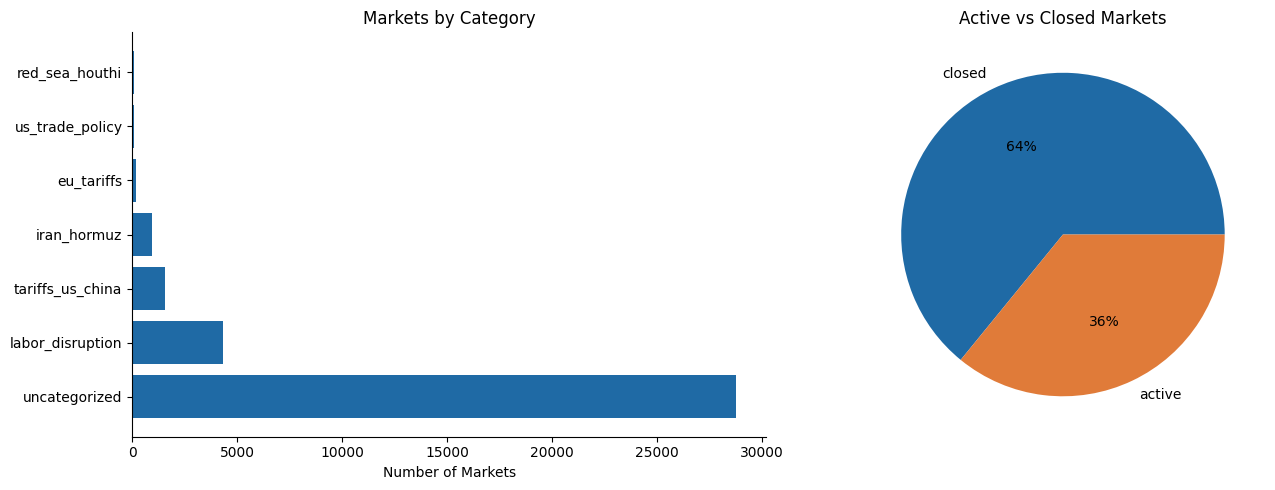

In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.facecolor'] = 'white'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Category distribution
cat_counts = markets_df['category'].fillna('uncategorized').value_counts()
axes[0].barh(cat_counts.index, cat_counts.values, color='#1f6aa5')
axes[0].set_xlabel('Number of Markets')
axes[0].set_title('Markets by Category')
for spine in ['top', 'right']:
    axes[0].spines[spine].set_visible(False)

# Status distribution
status_counts = markets_df['status'].value_counts()
axes[1].pie(status_counts.values, labels=status_counts.index, autopct='%1.0f%%',
            colors=['#1f6aa5', '#e07b39'])
axes[1].set_title('Active vs Closed Markets')

plt.tight_layout()
plt.savefig('../output/figures/market_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
top_by_volume = markets_df.nlargest(20, 'volume')[['title', 'category', 'status', 'volume']]
print('Top 20 markets by trading volume:')
top_by_volume

Top 20 markets by trading volume:


,title,category,status,volume
0,Will Donald Trump win the 2024 US Presidential Election?,NaN,closed,1.531479e+09
1,Will Kamala Harris win the 2024 US Presidential Election?,NaN,closed,1.037039e+09
2,Will Donald Trump be inaugurated?,NaN,closed,4.004095e+08
3,Will Nicolae Ciucă win the 2024 Romanian Presidential election?,NaN,closed,3.265077e+08
4,Will any other Republican Politician win the 2024 US Presidential Election?,NaN,closed,2.416551e+08
5,Will Michelle Obama win the 2024 US Presidential Election?,NaN,closed,1.533823e+08
6,Will Zohran Mamdani win the 2025 NYC mayoral election?,NaN,closed,1.432549e+08
7,Will Robert F. Kennedy Jr. win the 2024 US Presidential Election?,NaN,closed,1.416051e+08
8,Will Donald Trump win the popular vote in the 2024 Presidential Election?,NaN,closed,1.199326e+08
9,Will any other Democratic Politician win the 2024 US Presidential Election?,NaN,closed,1.165582e+08


## Summary
The discovery pipeline found the markets above. Proceed to 02_data_collection.ipynb to fetch price histories.